# Notebook for initial exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and process data

In [2]:
# load raw data
exp_raw = pd.read_csv('../data/raw/MicroarrayExpression.csv', index_col=0, header=None)
probes = pd.read_csv('../data/raw/Probes.csv', index_col='probe_id')
annotations = pd.read_csv('../data/raw/SampleAnnot.csv', index_col='structure_id')

In [3]:
# recode chromosome labels
group_map = {
    '19': 1, '17': 1, '16': 1, '22': 1,
    '11': 2, '20': 2,
    '1': 3, '2': 3, '3': 3,
    '6': 4, '7': 4, '8': 4, '9': 4, '12': 4, '15': 4,
    '4': 5, '5': 5, '10': 5, '13': 5, '14': 5, '18': 5, '21': 5, 'X': 5, 'Y': 5
}
probes['group'] = probes['chromosome'].astype(str).map(group_map)
probes['group'] = probes['group'].astype('Int64')

In [4]:
# annotate raw data
exp = exp_raw.copy()
exp.columns = annotations.index
exp_full = probes.join(exp, how='left').drop(columns=['probe_name', 'gene_id', 'gene_symbol', 'gene_name', 'entrez_id'])

In [5]:
from sklearn.model_selection import train_test_split

# filter out missing labels
exp_na = exp_full[exp_full['group'].isna()]
exp_use = exp_full[~exp_full['group'].isna()]

# split into training and testing sets
exp_train, exp_test = train_test_split(exp_use, test_size=0.2, random_state=42, stratify=exp_use['group'])

In [6]:
# save data
exp_full.to_pickle('../data/cleaned/exp_full.pkl')
exp_na.to_pickle('../data/cleaned/exp_na.pkl')
exp_train.to_pickle('../data/cleaned/exp_train.pkl')
exp_test.to_pickle('../data/cleaned/exp_test.pkl')

## EDA

In [41]:
exp_train.iloc[:, 2:].describe()

,4077,4323,4323,4440,4266,4267,4782,4784,4788,4251,...,4286,4146,4098,4289,4027,4751,4752,4758,4760,4761
count,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,...,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000
mean,5.197330,5.809651,5.980098,5.324711,5.854456,5.379166,5.756993,5.511338,5.855357,5.084750,...,5.542523,5.427031,5.434318,5.888775,5.428973,5.446904,5.427012,5.435670,5.372261,5.390832
std,2.789939,3.028977,3.037966,2.827453,3.002574,2.984948,3.013244,2.917524,3.048678,2.758396,...,2.976295,2.857927,2.887706,3.184702,2.932019,2.798802,2.822954,2.813783,2.824051,2.816682
min,1.473066,1.473066,1.473066,1.476725,1.473066,1.473066,1.473066,1.495682,1.473066,1.473066,...,1.473066,1.473066,1.473066,1.473066,1.492682,1.473066,1.473066,1.473066,1.473066,1.473066
25%,2.678582,2.908599,3.514687,2.926696,3.205259,2.526890,2.860716,2.936781,3.101558,2.272704,...,2.842455,3.098928,2.976945,2.969781,2.431008,3.079803,2.884894,3.007612,2.619387,2.766100
50%,5.079749,5.853832,5.497109,4.492199,5.472523,5.273047,5.778524,4.952860,5.586478,4.942152,...,5.379490,5.256400,5.246158,5.911829,5.142830,5.294610,5.283373,5.245361,5.173161,5.233189
75%,7.126172,7.974667,7.981529,7.259444,7.992758,7.521819,7.906597,7.596886,8.045977,7.054986,...,7.624970,7.394528,7.459189,8.143109,7.540756,7.377234,7.417443,7.350656,7.348972,7.344790
max,17.223805,18.381752,18.381752,18.381752,18.381752,18.381752,17.544386,17.853922,17.853922,17.853922,...,18.381752,17.167481,17.718814,18.381752,17.853922,17.718814,17.716896,17.497608,17.544386,17.544386


In [42]:
exp_train.iloc[:, 2:].describe().T.describe()

,count,mean,std,min,25%,50%,75%,max
count,946.0,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000
mean,38453.0,5.415801,2.903181,1.479545,2.751275,5.212896,7.462352,17.896131
std,0.0,0.194180,0.117985,0.033790,0.279517,0.269877,0.266473,0.477779
min,38453.0,4.801208,2.539321,1.473066,1.792266,3.793347,6.681509,16.067944
25%,38453.0,5.317741,2.822699,1.473066,2.585635,5.085603,7.318148,17.544386
50%,38453.0,5.395399,2.886676,1.473066,2.786872,5.208321,7.413826,17.853922
75%,38453.0,5.475532,2.961681,1.473066,2.940340,5.320019,7.573070,18.381752
max,38453.0,6.304218,3.487109,1.971789,3.801385,6.348750,8.843545,18.381752


In [43]:
exp_train.iloc[:, 2:].T.describe().T.describe()

,count,mean,std,min,25%,50%,75%,max
count,38453.0,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000,38453.000000
mean,946.0,5.415801,0.731663,3.156723,4.954625,5.393488,5.834901,8.638185
std,0.0,2.803545,0.292365,2.313811,2.841295,2.841872,2.828769,2.491039
min,946.0,1.652008,0.229850,1.473066,1.473066,1.505512,1.742160,2.866150
25%,946.0,2.829831,0.539672,1.473066,2.162697,2.743896,3.351457,6.828338
50%,946.0,5.165002,0.683538,1.896618,4.680135,5.176977,5.665704,8.419233
75%,946.0,7.375959,0.844911,4.294604,6.969239,7.384258,7.792388,10.143567
max,946.0,17.717181,3.629699,16.027749,17.497608,17.718814,18.381752,18.381752


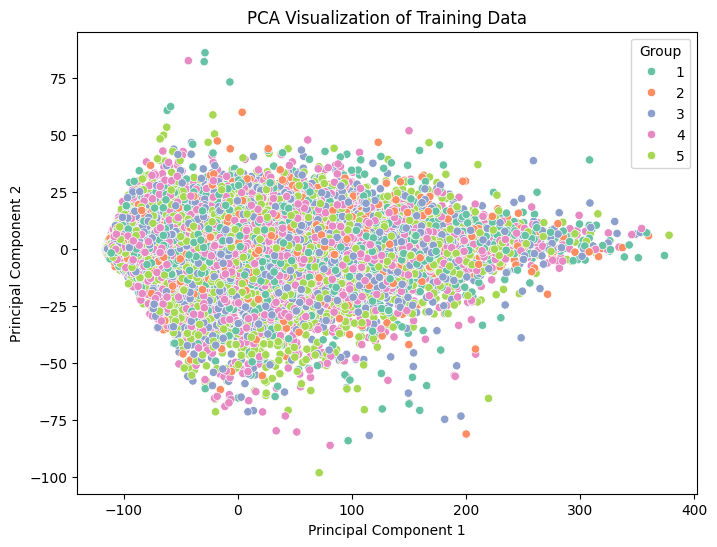

In [44]:
from sklearn.decomposition import PCA

# produce a 2d visualization using PCA
vis_pca = PCA(n_components=2)
X_vis = vis_pca.fit_transform(exp_train.iloc[:, 2:])
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=exp_train['group'], palette='Set2')
plt.title('PCA Visualization of Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Group')
plt.show()

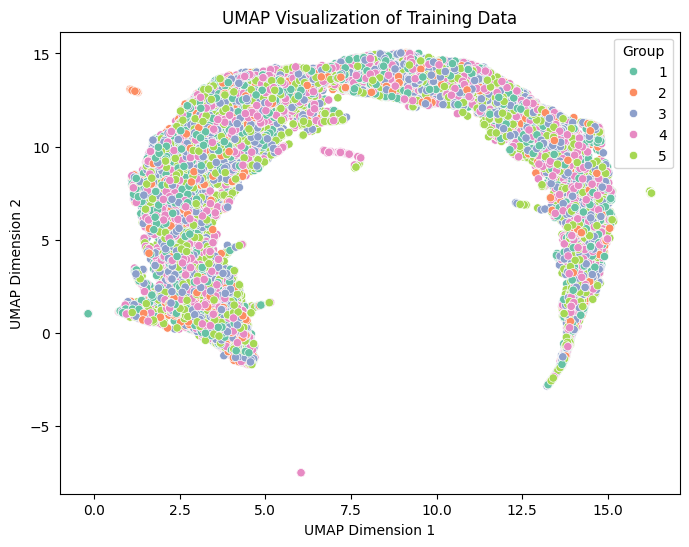

In [46]:
from umap import UMAP

# produce a 2d visualization using UMAP
vis_umap = UMAP(n_components=2)
X_vis_umap = vis_umap.fit_transform(exp_train.iloc[:, 2:])
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_vis_umap[:, 0], y=X_vis_umap[:, 1], hue=exp_train['group'], palette='Set2')
plt.title('UMAP Visualization of Training Data')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Group')
plt.show()

## Baseline test

In [9]:
from sklearn.model_selection import train_test_split

# split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    exp_train.drop(columns=['chromosome', 'group']),
    exp_train['group'].astype(int),
    test_size=0.2,
    random_state=42,
    stratify=exp_train['group']
)

In [22]:
# simplest baseline - KNN with no dimension reduction
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GridSearchCV

# train KNN classifier with minimal tuning
knn_param_grid = {'n_neighbors': list(range(1, 21, 2))}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, scoring='balanced_accuracy', cv=5, verbose=2)
knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_
y_pred = best_knn.predict(X_val)
print(knn_grid.best_params_, balanced_accuracy_score(y_val, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ......................................n_neighbors=1; total time=   1.7s
[CV] END ......................................n_neighbors=1; total time=   1.8s
[CV] END ......................................n_neighbors=1; total time=   2.6s
[CV] END ......................................n_neighbors=1; total time=   2.4s
[CV] END ......................................n_neighbors=1; total time=   2.7s
[CV] END ......................................n_neighbors=3; total time=   2.5s
[CV] END ......................................n_neighbors=3; total time=   2.6s
[CV] END ......................................n_neighbors=3; total time=   2.6s
[CV] END ......................................n_neighbors=3; total time=   3.8s
[CV] END ......................................n_neighbors=3; total time=   3.8s
[CV] END ......................................n_neighbors=5; total time=   3.7s
[CV] END ......................................n

In [23]:
pd.DataFrame(knn_grid.cv_results_).sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.206615,0.033541,2.102043,0.375214,1,{'n_neighbors': 1},0.234537,0.242408,0.237841,0.245818,0.249623,0.242045,0.005401,1
4,0.265116,0.060375,3.902077,0.074620,9,{'n_neighbors': 9},0.242127,0.230104,0.243538,0.242877,0.241437,0.240016,0.005006,2
1,0.222436,0.010472,2.924683,0.581160,3,{'n_neighbors': 3},0.240028,0.242054,0.237845,0.241400,0.236610,0.239587,0.002072,3
3,0.225385,0.011406,3.753126,0.176909,7,{'n_neighbors': 7},0.242598,0.235808,0.237920,0.241745,0.239217,0.239458,0.002483,4
2,0.236010,0.009762,4.035182,0.290533,5,{'n_neighbors': 5},0.239219,0.233622,0.241261,0.239035,0.241588,0.238945,0.002855,5
9,0.251755,0.015606,4.042939,0.036426,19,{'n_neighbors': 19},0.239736,0.231524,0.243204,0.244539,0.229067,0.237614,0.006227,6
8,0.246743,0.006971,4.038198,0.047789,17,{'n_neighbors': 17},0.238850,0.228001,0.241078,0.247885,0.231981,0.237559,0.006973,7
7,0.257930,0.037004,3.945817,0.333075,15,{'n_neighbors': 15},0.241720,0.226949,0.239137,0.245711,0.232079,0.237119,0.006751,8
5,0.264017,0.049849,3.990482,0.135030,11,{'n_neighbors': 11},0.240077,0.229432,0.236891,0.246111,0.233005,0.237103,0.005756,9
6,0.239720,0.028694,3.533416,0.531001,13,{'n_neighbors': 13},0.233249,0.228676,0.235397,0.244077,0.229519,0.234183,0.005519,10


In [17]:
# KNN after PCA dimension reduction
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# apply PCA before using KNN
pca_knn = Pipeline([
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'pca__n_components': [2, 10, 25, 50, 75, 100, 250, 500],
    'knn__n_neighbors': list(range(2, 21, 3))
}

grid = GridSearchCV(pca_knn, param_grid, scoring='balanced_accuracy', cv=5, verbose=2)
grid.fit(X_train, y_train)

best_pca_knn = grid.best_estimator_
y_pred = best_pca_knn.predict(X_val)
print(grid.best_params_, balanced_accuracy_score(y_val, y_pred))

Fitting 5 folds for each of 56 candidates, totalling 280 fits
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.9s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.9s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.8s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   1.0s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.9s
[CV] END ...........knn__n_neighbors=2, pca__n_components=10; total time=   1.0s
[CV] END ...........knn__n_neighbors=2, pca__n_components=10; total time=   1.0s
[CV] END ...........knn__n_neighbors=2, pca__n_components=10; total time=   1.0s
[CV] END ...........knn__n_neighbors=2, pca__n_components=10; total time=   1.0s
[CV] END ...........knn__n_neighbors=2, pca__n_components=10; total time=   1.1s
[CV] END ...........knn__n_neighbors=2, pca__n_components=25; total time=   2.7s
[CV] END ...........knn__n_neighbors=2, pca__n_

In [20]:
pd.DataFrame(grid.cv_results_).sort_values('rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,param_pca__n_components,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
22,4.720006,0.119539,1.414721,0.020672,8,250,"{'knn__n_neighbors': 8, 'pca__n_components': 250}",0.246122,0.233227,0.240471,0.244299,0.242563,0.241336,0.004465,1
21,3.806449,0.197353,0.739282,0.041074,8,100,"{'knn__n_neighbors': 8, 'pca__n_components': 100}",0.246079,0.229607,0.241109,0.244092,0.244071,0.240992,0.005909,2
55,4.464530,1.541955,2.092669,0.547259,20,500,"{'knn__n_neighbors': 20, 'pca__n_components': ...",0.243470,0.230873,0.245607,0.247394,0.235291,0.240527,0.006360,3
13,3.170035,0.175491,0.658006,0.038840,5,100,"{'knn__n_neighbors': 5, 'pca__n_components': 100}",0.246463,0.231830,0.235092,0.242037,0.244523,0.239989,0.005607,4
38,1.315593,0.089049,0.784080,0.006545,14,250,"{'knn__n_neighbors': 14, 'pca__n_components': ...",0.240747,0.231244,0.243499,0.245527,0.238848,0.239973,0.004926,5
